In [ ]:


# def image_to_graph(image_path):
#     # Read image
#     img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#         # Convert from BGR to RGB
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
#     # Create a mask for lightish gray color
#     bg = 110
#     tg = 210
#     lower_bound = np.array([bg, bg, bg])
#     upper_bound = np.array([tg, tg, tg])
#     mask = cv2.inRange(img, lower_bound, upper_bound)

#     # show the image
#     plt.imshow(img, cmap='gray')
    
#     print(img.shape)

#     # Average pixel values along the vertical axis
#     # avg_pixel_values = np.mean(img, axis=0)
#     # shift this graph doqn 100
#     avg_pixel_values = np.mean(mask, axis=0)
#     avg_pixel_values = avg_pixel_values + 50
#     # smooth the graph


#     # Generate graph
#     plt.plot(avg_pixel_values)
#     plt.title("Viewer Retention")
#     # make the plot longer
#     plt.figure(figsize=(20,10))
    
#     plt.show()

# # Test the function
# image_to_graph('screenshot.png')

In [ ]:
# def image_to_graph(image_path):
#     # Read image
#     img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    
#     # drastically increase the contrast
#     # img = cv2.convertScaleAbs(img, alpha=1, beta=40)

#     # Create a mask for lightish gray color
#     bg = 0
#     tg = 210
#     lower_bound = np.array([bg, bg, bg])
#     upper_bound = np.array([tg, tg, tg])
#     mask = cv2.inRange(img, lower_bound, upper_bound)

#     masked_img = cv2.bitwise_and(img, img, mask=mask)
    
#     # smooth the masked image to remove isolated pixels
#     kernel = np.ones((3,3),np.uint8)
#     masked_img = cv2.erode(masked_img,kernel,iterations = 2)
    
    

#     # # Plot original image
#     plt.figure(figsize=(20,10))
#     plt.imshow(img, cmap='gray')
#     plt.figure(figsize=(20,10))


#     plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))

#     # Initialize an empty list to hold heights of bars
#     bar_heights = []

#     # Loop through each column
#     for j in range(mask.shape[1]):
#         white_count = 0
#         for i in range(mask.shape[0] - 1, -1, -1):
#             if mask[i, j] == 255:  # Assuming white pixels have a value of 255
#                 white_count += 1
#             else:
#                 break
#         bar_heights.append(white_count)

#     # # Plotting the bar graph
#     # plt.bar(range(len(bar_heights)), bar_heights)
#     # plt.figure(figsize=(20,10))
#     # plt.show()
    
#     threshold = 10
#     for i in range(len(bar_heights)):
#         if bar_heights[i] < threshold:
#             bar_heights[i] = 0

#     return bar_heights

# # Test the function
# bar_heights = image_to_graph('screenshot_cropped.png')
# set all values of bar heights less than threshold to 0

# threshold = 10
# for i in range(len(bar_heights)):
#     if bar_heights[i] < threshold:
#         bar_heights[i] = 0
        
# # exclude clusters shorter than 10 pixels long by searching for series of not 0 values and setting them to 0 if they are shorter than threshold


# plt.figure(figsize=(20,10))
# plt.bar(range(len(bar_heights)), bar_heights)
# plt.figure(figsize=(20,10))
# plt.show()

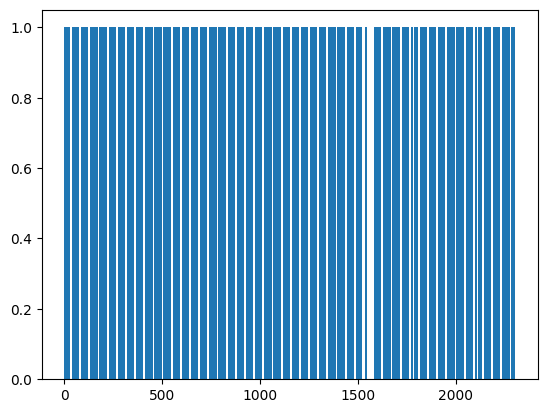

<Figure size 2000x1000 with 0 Axes>

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def filter_top_sequences(lst, n):
    start = None
    sequences = []
    
    # Find sequences of 1s
    for i, val in enumerate(lst):
        if val == 1 and start is None:
            start = i
        elif val == 0 and start is not None:
            sequences.append((start, i-1))
            start = None
            
    # Handle the case where the sequence reaches the end of the list
    if start is not None:
        sequences.append((start, len(lst) - 1))
        
    # Sort sequences by their lengths and keep the top 5
    sequences.sort(key=lambda x: x[1] - x[0], reverse=True)
    top_sequences = sequences[:n]
    
    # Create an output list that only includes the top 5 sequences of 1s
    output = [0] * len(lst)
    for start, end in top_sequences:
        for i in range(start, end + 1):
            output[i] = 1
            
    return output



def image_to_graph(image_path):
    # Read image
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    # Define a white threshold
    whiteness = 150
    threshold = np.array([whiteness, whiteness, whiteness])
    mask = (img >= threshold).all(axis=2)
    img[mask] = [0, 0, 0]
    
    # # Create a mask for blueness
    # blue_threshold = np.array([200, 50, 50])  # Assuming R,G,B format
    # mask_blue = (img >= blue_threshold).any(axis=2) & (img[:,:,0] > img[:,:,1]) & (img[:,:,0] > img[:,:,2])
    # img[mask_blue] = [0, 0, 0]


    # # # Plot original image
    # plt.figure(figsize=(20,10))
    # plt.imshow(img, cmap='gray')
    # plt.figure(figsize=(20,10))
    
    # create a bar graph by averaging the pixel values along the vertical axis
    avg_pixel_values = np.mean(img, axis=0)
    

    
    # average the RGB values but remove the blue values
    avg_pixel_values = np.mean(avg_pixel_values[:, :2], axis=1)
    # exclude red
    # avg_pixel_values = np.mean(avg_pixel_values[:, 1:], axis=1)


    # plt.plot(avg_pixel_values)
    # plt.title("Viewer Retention")
    # # make the plot longer
    # plt.figure(figsize=(20,10))
    # plt.show()
    
    threshold = 10 ### INTERESTING VALUE
    
    for i in range(len(avg_pixel_values)):
        if avg_pixel_values[i] < threshold:
            avg_pixel_values[i] = 0
            
    
    # convert average pixel values to a series of 0s if 0 and 1 if not 0
    avg_pixel_values = avg_pixel_values.tolist()

    avg_pixel_values = [0 if v == 0 else 1 for v in avg_pixel_values]

    avg_pixel_values = filter_top_sequences(avg_pixel_values, 9) ### INTERESTING VALUE
    
    # Plotting the bar graph
    plt.bar(range(len(avg_pixel_values)), avg_pixel_values)
    plt.figure(figsize=(20,10))
    plt.show()

    return avg_pixel_values

# Test the function
bar_heights = image_to_graph('screenshot_cropped.png')


In [3]:
from datetime import timedelta

def graph_to_times(total_time, bar_graph):
    # Convert total_time to seconds
    minutes, seconds = map(int, total_time.split(':'))
    total_seconds = minutes * 60 + seconds
    
    # Step to iterate through bar_graph
    step = total_seconds / len(bar_graph)

    # List to store time ranges
    time_ranges = []

    # Temporary variables to store start and end times of each significant peak
    start_time = None
    end_time = None

    for i, is_bar in enumerate(bar_graph):
        # Time corresponding to current data point
        current_time = i * step

        if is_bar:  # a bar is present
            if start_time is None:
                start_time = current_time
            end_time = current_time
        else:
            if start_time is not None:
                # Convert start_time and end_time to mm:ss format
                # start_str = str(timedelta(seconds=int(start_time)))
                # end_str = str(timedelta(seconds=int(end_time)))
                total_time_secs = int(end_time) - int(start_time)
                time_ranges.append((int(start_time), int(start_time)/total_seconds, total_time_secs))
                start_time = None
                end_time = None

    return time_ranges

# Example usage
total_time = "14:45"
bar_graph = bar_heights  # Replace with your actual data
time_ranges = graph_to_times(total_time, bar_graph)
print(time_ranges)


[(0, 0.0, 584), (587, 0.6632768361581921, 7), (604, 0.6824858757062147, 30), (635, 0.7175141242937854, 49), (685, 0.7740112994350282, 0), (686, 0.7751412429378531, 9), (696, 0.7864406779661017, 96), (792, 0.8949152542372881, 18)]


video length:  0:13


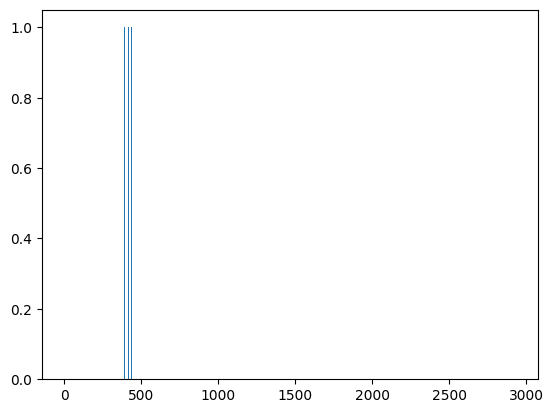

<Figure size 2000x1000 with 0 Axes>

In [8]:
import time
# import selenium driver chrome
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import pyautogui

from PIL import Image

def prepare_video(url):    
    options = Options()
    options.add_extension('./adblock.crx')
    options.add_argument("load-extension=./adblock.crx")

    driver = webdriver.Chrome(options=options)
    # Inject JS to make video black


    # get the site
    driver.get(url)


    time.sleep(10)

    # press c for closed captions off
    progress_bar = driver.find_element(By.CLASS_NAME, "ytp-progress-bar")

    # Focus on video player by clicking it
    # video_player = driver.find_element_by_css_selector('video')
    progress_bar.click()
    
    # time.sleep(3)

    # Initialize ActionChains
    actions = ActionChains(driver)

    # Send 'c' key to disable closed captions
    actions.send_keys('c')
    actions.perform()

    # Clear actions
    actions.reset_actions()

    # Send 'f' key to go fullscreen
    actions.send_keys('f')
    actions.perform()
    actions.reset_actions()


    # fullscreen_button = driver.find_element(By.CLASS_NAME, "ytp-fullscreen-button ytp-button")
    # driver.find_element(By.CLASS_NAME, "ytp-subtitles-button ytp-button").click()

    driver.execute_script("""
    var video = document.querySelector('video');
    video.style.filter = 'brightness(0)';
    """)
    time.sleep(3)
    
        # Get screen size
    screen_width, screen_height = pyautogui.size()

    # Calculate coordinates based on screen size. Example: center of the screen
    center_x = screen_width / 2
    bar_y = screen_height * (1- 0.07077)

    # Move the mouse to the calculated coordinates
    pyautogui.moveTo(center_x, bar_y)

    video_length = driver.find_element(By.CLASS_NAME, "ytp-time-duration").text
    print("video length: ", video_length)

    # get the screenshot of the whole page
    driver.save_screenshot("screenshot.png")

    # image is 2880 x 1622
    # crop by percentage to cut 48 pixels off the left and right, 1400 pixels off the top, and 120 pixels off the bottom.
    # then display the image    
    # Load image
    im = Image.open('screenshot.png')

    # Image dimensions
    width, height = im.size

    # Calculate crop coordinates
    left = 48  # 48 pixels from the left
    top = 1400  # 1400 pixels from the top
    right = width - 48  # 48 pixels from the right
    bottom = height - 125 # 125 pixels from the bottom

    # Crop
    im_cropped = im.crop((left, top, right, bottom))

    # Save and display
    im_cropped.save('screenshot_cropped.png')
    # im_cropped.show()

    bar_heights = image_to_graph('screenshot_cropped.png')
    time_ranges = graph_to_times(video_length, bar_heights)
    # driver.close()
    for t in time_ranges:
        start_time = t[0]
        sleepy_time = t[2]
        
        new_url = url + "?feature=shared&t=" + str(start_time)
        driver.get(new_url)
        
        time.sleep(sleepy_time+1)
        
    driver.close()
    driver.quit()

    return time_ranges, driver, actions

url = "https://www.youtube.com/watch?v=yhB3BgJyGl8"
time_ranges, driver, actions = prepare_video(url)




In [19]:
# https://youtu.be/48h57PspBec?feature=shared&t=72


    

InvalidSessionIdException: Message: invalid session id
Stacktrace:
0   chromedriver                        0x00000001033a8510 chromedriver + 4310288
1   chromedriver                        0x00000001033a04bc chromedriver + 4277436
2   chromedriver                        0x0000000102fd39c4 chromedriver + 293316
3   chromedriver                        0x000000010300c798 chromedriver + 526232
4   chromedriver                        0x00000001030374a4 chromedriver + 701604
5   chromedriver                        0x0000000103036b08 chromedriver + 699144
6   chromedriver                        0x0000000102fa26ac chromedriver + 91820
7   chromedriver                        0x000000010336e834 chromedriver + 4073524
8   chromedriver                        0x00000001033727fc chromedriver + 4089852
9   chromedriver                        0x0000000103372c58 chromedriver + 4090968
10  chromedriver                        0x00000001033788f8 chromedriver + 4114680
11  chromedriver                     

video length:  36:46
1400 1661


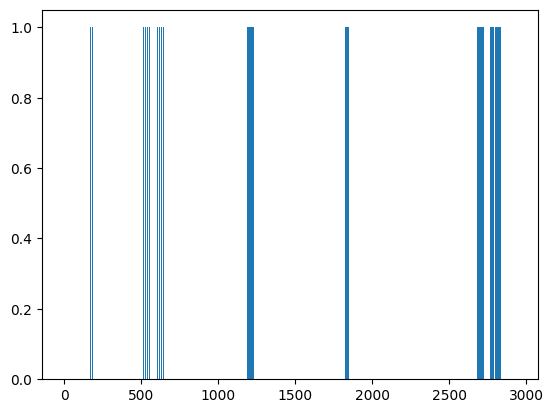

<Figure size 2000x1000 with 0 Axes>

attempted to click time 119 at location 104.04424297370811
attempted to click time 383 at location 278.959202175884


KeyboardInterrupt: 

In [11]:
import time
# import selenium driver chrome
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import pyautogui

from PIL import Image

def prepare_video(url):    
    options = Options()
    options.add_extension('./adblock.crx')
    options.add_argument("load-extension=./adblock.crx")

    driver = webdriver.Chrome(options=options)
    # Inject JS to make video black


    # get the site
    driver.get(url)


    time.sleep(15)

    # press c for closed captions off
    progress_bar = driver.find_element(By.CLASS_NAME, "ytp-progress-bar")

    # Focus on video player by clicking it
    # video_player = driver.find_element_by_css_selector('video')
    progress_bar.click()
    
    # time.sleep(3)

    # Initialize ActionChains
    actions = ActionChains(driver)

    # Send 'c' key to disable closed captions
    actions.send_keys('c')
    actions.perform()

    # Clear actions
    actions.reset_actions()

    # Send 'f' key to go fullscreen
    actions.send_keys('f')
    actions.perform()
    actions.reset_actions()


    # fullscreen_button = driver.find_element(By.CLASS_NAME, "ytp-fullscreen-button ytp-button")
    # driver.find_element(By.CLASS_NAME, "ytp-subtitles-button ytp-button").click()
    driver.execute_script("""
    var video = document.querySelector('video');
    video.style.filter = 'brightness(0)';
    """)

    time.sleep(3)

        # Get screen size
    screen_width, screen_height = pyautogui.size()

    # Calculate coordinates based on screen size. Example: center of the screen
    center_x = screen_width / 2
    bar_y = screen_height * (1- 0.07077)

    # Move the mouse to the calculated coordinates
    pyautogui.moveTo(center_x, bar_y)
    video_length = driver.find_element(By.CLASS_NAME, "ytp-time-duration").text
    print("video length: ", video_length)

    time.sleep(2)
    # get the screenshot of the whole page
    driver.save_screenshot("screenshot.png")

    # image is 2880 x 1622
    # crop by percentage to cut 48 pixels off the left and right, 1400 pixels off the top, and 120 pixels off the bottom.
    # then display the image    
    # Load image
    im = Image.open('screenshot.png')

    # Image dimensions
    width, height = im.size

    # Calculate crop coordinates
    offset_x = 48 #48 my screen
    offset_y = 125 # 125 my screen
    left = offset_x  # 48 pixels from the left
    top = 1400  # 1400 pixels from the top
    right = width - offset_x  # 48 pixels from the right
    bottom = height - offset_y # 125 pixels from the bottom
    print(top,bottom)

    # Crop
    im_cropped = im.crop((left, top, right, bottom))

    # Save and display
    im_cropped.save('screenshot_cropped.png')
    # im_cropped.show()

    bar_heights = image_to_graph('screenshot_cropped.png')
    time_ranges = graph_to_times(video_length, bar_heights)
    # driver.close()
    driver.execute_script("""
    var video = document.querySelector('video');
    video.style.filter = 'brightness(1)';
    """)
    
    # make the mouse disappear
    pyautogui.moveTo(1, 1)
    

    for t in time_ranges:
        # instead lets try using pyautogui
        start_percentage = t[1]
        sleepy_time = t[2]

        # image is 2880 x 1622
        # y is bar_y
        
        # get the ratio of the bars to the screen width
        player_to_screen_ratio = (2880-96) / 2880
        player_bar_width = screen_width * player_to_screen_ratio
        player_bar_offset = (screen_width - player_bar_width) / 2
        start_x = player_bar_offset + (player_bar_width * start_percentage)

        pyautogui.moveTo(start_x, bar_y)
        # left click 
        pyautogui.click()
        
        print('attempted to click time ' + str(t[0]) + ' at location ' + str(start_x))
        pyautogui.moveTo(1, 1)

        time.sleep(sleepy_time+1)
        

        
    driver.close()
    driver.quit()

    return time_ranges, driver, actions

url = "https://www.youtube.com/watch?v=JcJSW7Rprio"
time_ranges, driver, actions = prepare_video(url)



